Generating matrices...
T=1  →  1.28s  (0.0213 min)
T=2  →  1.16s  (0.0194 min)
T=3  →  0.74s  (0.0123 min)
T=4  →  1.37s  (0.0228 min)
T=5  →  1.56s  (0.0260 min)
T=6  →  0.78s  (0.0130 min)
T=7  →  0.70s  (0.0117 min)
T=8  →  0.59s  (0.0098 min)

Threads  | T=1 | T=2 | T=3 | T=4 | T=5 | T=6 | T=7 | T=8
Time(min)| 0.0213 | 0.0194 | 0.0123 | 0.0228 | 0.0260 | 0.0130 | 0.0117 | 0.0098


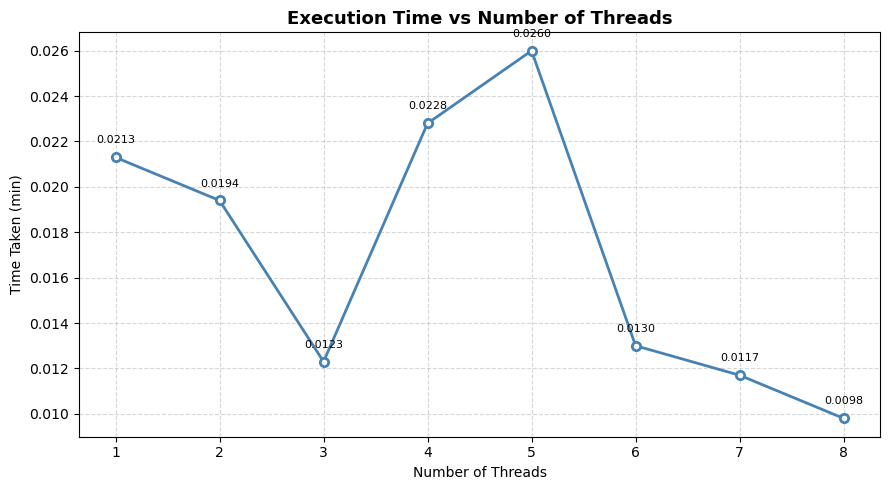

Plot saved as execution_time.png


In [2]:
import numpy as np
import threading
import time
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

# ── Configuration ──────────────────────────────────────────────────────────────
NUM_MATRICES = 50            # 500 × 5k matrices ≈ 50 GB — reduced to fit in RAM
MATRIX_SIZE  = 1000          # 1k x 1k  (~4 MB each → ~200 MB total input)
MAX_THREADS  = 8

# ── Generate data ──────────────────────────────────────────────────────────────
print("Generating matrices...")
constant_matrix = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float32)
random_matrices  = [np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float32)
                    for _ in range(NUM_MATRICES)]

results = [None] * NUM_MATRICES          # pre-allocate result slots

# ── Worker function ────────────────────────────────────────────────────────────
def multiply_chunk(indices):
    """Multiply a subset of matrices and store results."""
    for i in indices:
        results[i] = np.dot(random_matrices[i], constant_matrix)

# ── Benchmark across T = 1 … MAX_THREADS ──────────────────────────────────────
thread_counts = list(range(1, MAX_THREADS + 1))
times_taken   = []

for T in thread_counts:
    # Split matrix indices into T roughly equal chunks
    all_indices = list(range(NUM_MATRICES))
    chunks = [all_indices[i::T] for i in range(T)]

    threads = [threading.Thread(target=multiply_chunk, args=(chunk,))
               for chunk in chunks]

    start = time.time()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    elapsed = time.time() - start

    times_taken.append(round(elapsed / 60, 4))   # convert seconds → minutes
    print(f"T={T}  →  {elapsed:.2f}s  ({times_taken[-1]:.4f} min)")

# ── Print result table ─────────────────────────────────────────────────────────
print("\n" + "="*60)
header = "Threads  | " + " | ".join(f"T={t}" for t in thread_counts)
row    = "Time(min)| " + " | ".join(f"{v:.4f}" for v in times_taken)
print(header)
print(row)
print("="*60)

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(thread_counts, times_taken, marker='o', linewidth=2,
         color='steelblue', markerfacecolor='white', markeredgewidth=2)

for x, y in zip(thread_counts, times_taken):
    plt.annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=8)

plt.title("Execution Time vs Number of Threads", fontsize=13, fontweight='bold')
plt.xlabel("Number of Threads")
plt.ylabel("Time Taken (min)")
plt.xticks(thread_counts)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("execution_time.png", dpi=150)
plt.show()
print("Plot saved as execution_time.png")